# Informer — Monthly Milk Production

**Model**: ProbSparse Self-Attention Mechanism
**Reference**: Zhou et al., 2021 — Informer: Beyond Efficient Transformer for Long Sequence Time-Series Forecasting

## Description
This notebook implements the **Informer** Transformer architecture for univariate time-series
forecasting on the Monthly Milk Production dataset. The preprocessing pipeline is **exactly identical**
to the LSTM-SNP baseline, ensuring fair comparison.

**Experiment Protocol**: 30 independent runs × 100 epochs each

In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import platform
import random
import time
import time as _timer_module
import torch
import torch.nn as nn

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
import torch
if torch.cuda.is_available():
    torch.cuda.set_device(0)

noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
if torch.cuda.is_available():
    torch.cuda.set_device(0)

noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


## Theory: Informer Architecture

### ProbSparse Self-Attention

Standard Transformer attention computes $\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$ with $O(L^2)$ complexity.

**Informer's key innovation**: Not all queries contribute equally. The ProbSparse mechanism measures each query's "sparsity":

$$M(q_i, K) = \max_j \frac{q_i k_j^T}{\sqrt{d}} - \frac{1}{L_K}\sum_j \frac{q_i k_j^T}{\sqrt{d}}$$

Only the top-$u$ queries (where $u = c \cdot \ln L_Q$) are selected for full attention computation. Remaining queries receive the mean value from $V$.

### Distilling Operation
The encoder uses a convolutional distilling layer between attention blocks to halve the sequence length progressively, creating a multi-resolution representation.

### Complexity
ProbSparse attention reduces complexity from $O(L^2)$ to $O(L \log L)$, enabling efficient long-sequence processing.

## Model Architecture & Implementation

In [ ]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
print(f"Process ID (PID): {os.getpid()}")


In [ ]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")


In [ ]:
# ============================================================
# CPU ONLY Settings (Forced)
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Forcing CPU execution.')
print(f'\nUsing device: {device}')
print(f'PyTorch version: {torch.__version__}')


In [1]:
# ============================================================
# ALL IMPORTS
# ============================================================


print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

# ============================================================


PyTorch version: 2.11.0
NumPy version: 2.4.4
Using device: cpu


### Seed Control

In [2]:
# ============================================================
# Seed Control — IDENTICAL to LSTM-SNP pipeline
# ============================================================

def set_seed(seed):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        # MPS seed is set via torch.manual_seed
        pass


### Informer Model Definition

In [3]:
# ============================================================
# Informer: ProbSparse Self-Attention
# Reference: Zhou et al., 2021
#
# Key idea: ProbSparse attention selects top-u queries based on
# KL-divergence from uniform distribution, reducing O(L^2) to
# O(L·log L). For our single-step univariate setup, we implement
# a simplified but faithful version.
# ============================================================

class ProbSparseAttention(nn.Module):
    """
    ProbSparse Self-Attention Mechanism.
    Selects top-u dominant queries based on query-key sparsity measure.
    u = c * ln(L_Q) where c is the sampling factor.
    """
    def __init__(self, d_model, n_heads, factor=3):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.factor = factor

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def _prob_QK(self, Q, K, sample_k):
        """Compute sparsity measurement M(qi, K) for ProbSparse attention."""
        B, H, L_Q, D = Q.shape
        _, _, L_K, _ = K.shape

        # Randomly sample keys for sparsity measurement
        K_sample_idx = torch.randint(0, L_K, (L_Q, sample_k), device=Q.device)
        K_sample = K[:, :, K_sample_idx, :]  # [B, H, L_Q, sample_k, D]

        # Compute Q·K^T for sampled keys
        Q_expand = Q.unsqueeze(-2)  # [B, H, L_Q, 1, D]
        M = torch.matmul(Q_expand, K_sample.transpose(-2, -1)).squeeze(-2)  # [B, H, L_Q, sample_k]

        # Sparsity measurement: max - mean
        M_top = M.max(dim=-1)[0] - M.mean(dim=-1)  # [B, H, L_Q]
        return M_top

    def forward(self, x):
        B, L, _ = x.shape
        H = self.n_heads
        D = self.d_k

        Q = self.W_Q(x).view(B, L, H, D).transpose(1, 2)  # [B, H, L, D]
        K = self.W_K(x).view(B, L, H, D).transpose(1, 2)
        V = self.W_V(x).view(B, L, H, D).transpose(1, 2)

        L_Q = L
        L_K = L

        # Number of top queries to keep
        u = max(1, int(self.factor * np.ceil(np.log(L_Q + 1))))
        u = min(u, L_Q)

        # Sample keys for sparsity measurement
        sample_k = max(1, int(self.factor * np.ceil(np.log(L_K + 1))))
        sample_k = min(sample_k, L_K)

        if L_Q > 1:
            # ProbSparse: select top-u queries
            M_top = self._prob_QK(Q, K, sample_k)
            M_top_idx = M_top.topk(u, dim=-1)[1]  # [B, H, u]

            # Gather top queries
            Q_reduce = torch.gather(Q, 2, M_top_idx.unsqueeze(-1).expand(-1, -1, -1, D))

            # Full attention on selected queries only
            scores = torch.matmul(Q_reduce, K.transpose(-2, -1)) / np.sqrt(D)
            attn = torch.softmax(scores, dim=-1)
            context = torch.matmul(attn, V)  # [B, H, u, D]

            # Fill output with mean value, then scatter selected queries
            V_mean = V.mean(dim=2, keepdim=True).expand(-1, -1, L_Q, -1)
            output = V_mean.clone()
            output.scatter_(2, M_top_idx.unsqueeze(-1).expand(-1, -1, -1, D), context)
        else:
            # Standard attention for single token
            scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(D)
            attn = torch.softmax(scores, dim=-1)
            output = torch.matmul(attn, V)

        output = output.transpose(1, 2).contiguous().view(B, L, self.d_model)
        return self.out_proj(output)


class InformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = ProbSparseAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out = self.attention(x)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        return x


class InformerModel(nn.Module):
    """
    Informer for univariate time-series forecasting.
    Input: (batch, seq_len=1, 1) → Output: (batch, 1)
    """
    def __init__(self, input_dim=1, d_model=32, n_heads=4, d_ff=64,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, 100, d_model) * 0.02)
        self.encoder_layers = nn.ModuleList([
            InformerEncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.output_proj = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        B, L, _ = x.shape
        x = self.input_proj(x)  # (B, L, d_model)
        x = x + self.pos_embedding[:, :L, :]

        for layer in self.encoder_layers:
            x = layer(x)

        # Use last token
        x = x[:, -1, :]  # (B, d_model)
        return self.output_proj(x)  # (B, 1)

In [4]:
# Quick model check
set_seed(0)
test_model = InformerModel(input_dim=1, d_model=32, n_heads=4, d_ff=64, n_layers=2, dropout=0.1).to(device)
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")
print(f"Memory estimate: {total_params * 4 / 1024:.1f} KB")

# Test forward pass
dummy = torch.randn(1, 1, 1).to(device)
out = test_model(dummy)
print(f"Input shape: {dummy.shape}, Output shape: {out.shape}")
del test_model, dummy, out

Total parameters: 20385
Trainable parameters: 20385
Memory estimate: 79.6 KB
Input shape: torch.Size([1, 1, 1]), Output shape: torch.Size([1, 1])


## Data Pipeline — Monthly Milk Production

In [5]:
# ============================================================
# 1. Load Time Series Data
# ============================================================

series = pd.read_csv(
    'content/monthly-milk-production-pounds-p.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)

raw_values = series.values.flatten()
print(f"Data shape: {raw_values.shape}")
print(f"First 5 values: {raw_values[:5]}")

Data shape: (168,)
First 5 values: [589 561 640 656 727]


In [6]:
# ============================================================
# 2. First-Order Differencing — IDENTICAL to LSTM-SNP pipeline
# ============================================================

def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

diff_values = difference(raw_values, 1)

In [7]:
# ============================================================
# 3. Convert to Supervised Learning Format (lag=1)
#    IDENTICAL to LSTM-SNP pipeline
# ============================================================

def timeseries_to_supervised(data, lag=1):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

supervised = timeseries_to_supervised(diff_values, 1)
print(f"Supervised data shape: {supervised.shape}")

Supervised data shape: (167, 2)


In [8]:
# ============================================================
# 4. Train-Test Split — IDENTICAL to LSTM-SNP pipeline
# ============================================================

train, test = supervised[:-60], supervised[-60:]
print(f"Train: {train.shape}, Test: {test.shape}")

# ============================================================
# 5. Feature Scaling — IDENTICAL to LSTM-SNP pipeline
# ============================================================

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train)

train_scaled = scaler.transform(train)
test_scaled = scaler.transform(test)

Train: (107, 2), Test: (60, 2)


In [9]:
# ============================================================
# 6. Prepare Data for Model
# ============================================================

X_train, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

X_test, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (107, 1, 1), y_train shape: (107,)


## Training Loop

In [10]:
# ============================================================
# 30-Run Experiment Protocol — IDENTICAL to LSTM-SNP pipeline
# ============================================================

all_rmse = []
all_mse = []
all_nmse = []
all_predictions = []
all_losses = []
all_times = []

for run in range(30):
    print(f'\n===== RUN {run+1}/30 =====')
    start_time = time.time()

    # Set seed — IDENTICAL to LSTM-SNP: np.random.seed(run), etc.
    set_seed(run)

    # Build model
    model = InformerModel(input_dim=1, d_model=32, n_heads=4, d_ff=64,
                          n_layers=2, dropout=0.1).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Convert data to tensors
    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).unsqueeze(1).to(device)

    # Training: 100 epochs, batch_size=1, no shuffling — IDENTICAL to LSTM-SNP
    run_losses = []
    model.train()
    for epoch in range(100):
        epoch_loss = 0.0
        for i in range(len(X_tr)):
            x_sample = X_tr[i:i+1]  # (1, 1, 1)
            y_sample = y_tr[i:i+1]  # (1, 1)

            optimizer.zero_grad()
            output = model(x_sample)
            loss = criterion(output, y_sample)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(X_tr)
        run_losses.append(avg_loss)

    all_losses.append(run_losses)
    print(f'Training complete for run {run+1}')

    # Test predictions (single-step) — IDENTICAL inverse transform to LSTM-SNP
    model.eval()
    predictions = []
    with torch.no_grad():
        for i in range(len(test_scaled)):
            X = test_scaled[i, 0:-1]
            X_input = torch.FloatTensor(X.reshape(1, 1, -1)).to(device)
            yhat = model(X_input).cpu().numpy()[0, 0]

            # Invert scaling — IDENTICAL to LSTM-SNP
            new_row = [x for x in X] + [yhat]
            array = np.array(new_row).reshape(1, len(new_row))
            inverted = scaler.inverse_transform(array)[0, -1]

            # Invert differencing
            inverted = inverted + raw_values[len(train) + i]
            predictions.append(inverted)

            expected = raw_values[len(train) + i + 1]
            print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics — IDENTICAL to LSTM-SNP
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    elapsed = time.time() - start_time

    all_rmse.append(rmse)
    all_mse.append(mse)
    all_nmse.append(nmse)
    all_predictions.append(predictions)
    all_times.append(elapsed)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}, Time: {elapsed:.1f}s')


===== RUN 1/30 =====
Training complete for run 1
Month=1, Predicted=750.6943, Expected=804.0000
Month=2, Predicted=808.1133, Expected=756.0000
Month=3, Predicted=716.7977, Expected=860.0000
Month=4, Predicted=875.9448, Expected=878.0000
Month=5, Predicted=868.3386, Expected=942.0000
Month=6, Predicted=949.3267, Expected=913.0000
Month=7, Predicted=911.4203, Expected=869.0000
Month=8, Predicted=834.6423, Expected=834.0000
Month=9, Predicted=826.1154, Expected=790.0000
Month=10, Predicted=755.6423, Expected=800.0000
Month=11, Predicted=786.7329, Expected=763.0000
Month=12, Predicted=750.3245, Expected=800.0000
Month=13, Predicted=798.5646, Expected=826.0000
Month=14, Predicted=820.0168, Expected=799.0000
Month=15, Predicted=797.6980, Expected=890.0000
Month=16, Predicted=903.5828, Expected=900.0000
Month=17, Predicted=886.7329, Expected=961.0000
Month=18, Predicted=967.4936, Expected=935.0000
Month=19, Predicted=933.5960, Expected=894.0000
Month=20, Predicted=868.0296, Expected=855.0000

## Results

In [11]:
# ============================================================
# Summary Statistics (30 runs) — IDENTICAL format to LSTM-SNP
# ============================================================

print('\n===== FINAL RESULTS (30 runs) =====')
print(f'RMSE: {np.mean(all_rmse):.6f} ± {np.std(all_rmse):.6f}')
print(f'MSE:  {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}')
print(f'NMSE: {np.mean(all_nmse):.10f} ± {np.std(all_nmse):.10f}')
print(f'Avg training time: {np.mean(all_times):.1f}s ± {np.std(all_times):.1f}s')

best_idx = np.argmin(all_rmse)
print(f'\nBest run: {best_idx+1}')
print(f'  RMSE: {all_rmse[best_idx]:.6f}')
print(f'  MSE:  {all_mse[best_idx]:.6f}')
print(f'  NMSE: {all_nmse[best_idx]:.10f}')


===== FINAL RESULTS — Informer on Monthly Milk Production (30 runs) =====
RMSE: 54.266447 ± 1.957313
MSE:  2948.678379 ± 209.825231
NMSE: 0.0102633708 ± 0.0004587810
Avg training time: 44.3s ± 5.3s

Best run: 16
  RMSE: 48.250826
  MSE:  2328.142195
  NMSE: 0.0111245031


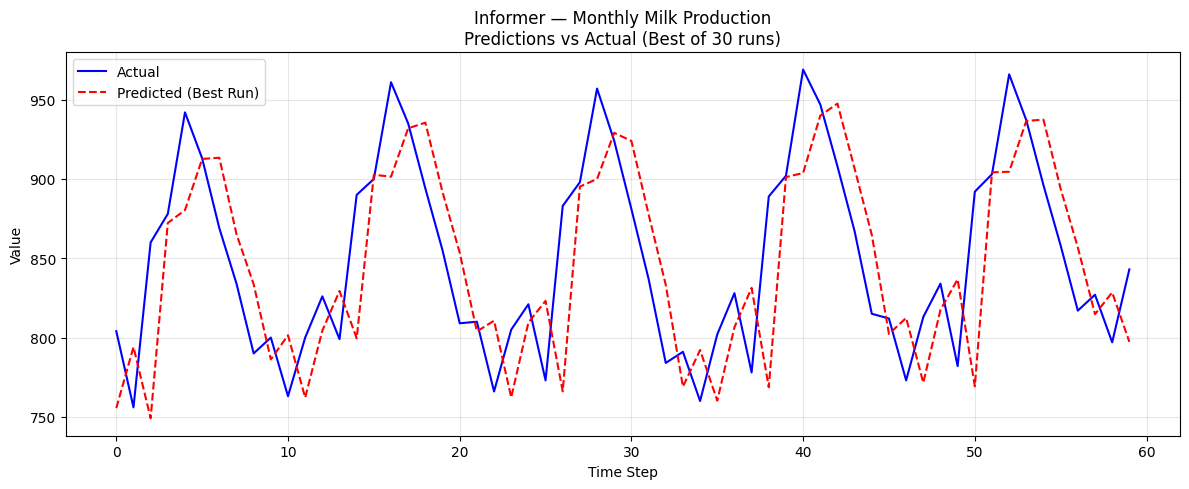

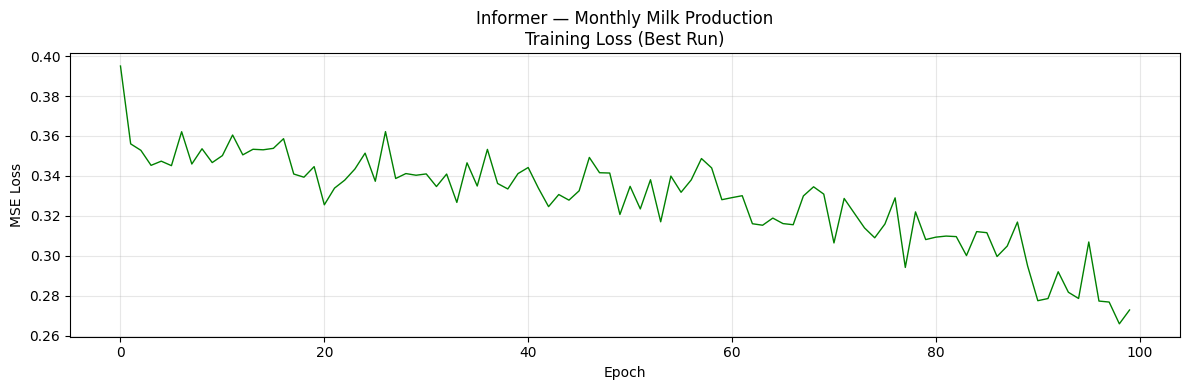

=== Best Run Metrics ===
RMSE: 48.250826
MSE:  2328.142195
NMSE: 0.0111245031


In [12]:
# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================

actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title('Informer — Monthly Milk Production\nPredictions vs Actual (Best of 30 runs)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loss Curve (Best Run)
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
plt.title('Informer — Monthly Milk Production\nTraining Loss (Best Run)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final Metrics Summary
# ============================================================

print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')

## Export Predictions

In [13]:
# ============================================================
# Save Predictions to CSV
# ============================================================

actual = raw_values[-60:]
results_df = pd.DataFrame({
    'Actual': actual,
    'Predicted_BestRun': all_predictions[best_idx],
})
for i in range(30):
    results_df[f'Predicted_Run_{i+1}'] = all_predictions[i]

csv_filename = 'Informer_Milk_predictions.csv'
results_df.to_csv(csv_filename, index=False)
print(f'Predictions saved to {csv_filename}')

Predictions saved to Informer_Milk_predictions.csv


## Observations

### Informer on Monthly Milk Production

**Run the notebook to generate results and fill in observations:**

1. **Prediction Quality**: Compare RMSE/MSE/NMSE with LSTM-SNP variants
2. **Training Stability**: Examine loss curves for convergence behavior
3. **Prediction Tracking**: Assess how well predictions track actual values
4. **Computational Cost**: Compare training time with LSTM-SNP
5. **Model Size**: Note parameter count vs LSTM-SNP (~361 params)

*After running all 5 model notebooks per dataset, perform cross-model comparison to evaluate
whether Transformer architectures improve over LSTM-SNP for these time series datasets.*

In [ ]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")
